<a href="https://colab.research.google.com/github/rayvankaazrifany/Tugas-Besar-NLP/blob/main/NLP_AspectLabelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Data

In [ ]:
import pandas as pd

# Assuming the file is named 'preprocessed_pizza.xlsx'
# and is in the same directory as this notebook.
try:
    df_reviews = pd.read_excel('preprocessed_pizza.xlsx')
    print("Excel file loaded successfully!")
    print(df_reviews.head())
except FileNotFoundError:
    print("Error: The file 'preprocessed_pizza.xlsx' was not found.")
    print("Please make sure the file is in the correct directory or provide the full path.")
except Exception as e:
    print(f"An error occurred: {e}")

Excel file loaded successfully!
  cabang                                             ulasan sentiment  \
0   Dago            pizzanya enak, penasaran coba menu lain  positive   
1   Dago                         makanan enak pelayanan oke  positive   
2   Dago                   Menarik mas nya ramah pizza enak  positive   
3   Dago  Pizza nya enak, lembut dan kriuk, tidak alot\n...  positive   
4   Dago                                     best cheeseeee  negative   

                                          text_clean  \
0           pizza nya enak  penasaran coba menu lain   
1                         makanan enak pelayanan oke   
2                   Menarik mas nya ramah pizza enak   
3  Pizza nya enak  lembut dan kriuk  tidak alot h...   
4                                     best cheeseeee   

                                text_casefoldingText  \
0           pizza nya enak  penasaran coba menu lain   
1                         makanan enak pelayanan oke   
2                   mena

In [ ]:
import json

# 1. Load the aspect dictionary
with open('aspect_dictionary_pizza.json', 'r', encoding='utf-8') as f:
    aspect_dictionary = json.load(f)

# 2. Define a classification function
def classify_aspect(text, aspect_dict):
    found_aspects = []
    # Ensure text is a string and convert to lower for case-insensitive matching
    text_lower = str(text).lower()

    for aspect, keywords in aspect_dict.items():
        for keyword in keywords:
            if keyword.lower() in text_lower:
                found_aspects.append(aspect)
                break  # Move to the next aspect once a keyword is found for the current aspect
    return found_aspects if found_aspects else ["None"]  # Return "None" if no aspects are found

# 3. Apply the function to the 'text_akhir' column
df_reviews['aspect_classification'] = df_reviews['text_akhir'].apply(lambda x: classify_aspect(x, aspect_dictionary))

# 4. Display the results
print("DataFrame with new 'aspect_classification' column:")
print(df_reviews[['text_akhir', 'aspect_classification']].head())

DataFrame with new 'aspect_classification' column:
                                          text_akhir  \
0                 pizza nya enak penasaran coba menu   
1                               makan enak layan oke   
2                     tarik mas nya ramah pizza enak   
3  pizza nya enak lembut renyah alot harga nya mu...   
4                                     best cheeseeee   

                             aspect_classification  
0                                        [makanan]  
1                             [makanan, pelayanan]  
2                             [makanan, pelayanan]  
3  [makanan, pelayanan, harga, suasana, fasilitas]  
4                             [makanan, pelayanan]  


In [ ]:
output_file_name = 'sentiment_aspect_analysis.xlsx'
df_reviews.to_excel(output_file_name, index=False)
print(f"Dataset berhasil diekspor ke '{output_file_name}'")

Dataset berhasil diekspor ke 'sentiment_aspect_analysis.xlsx'


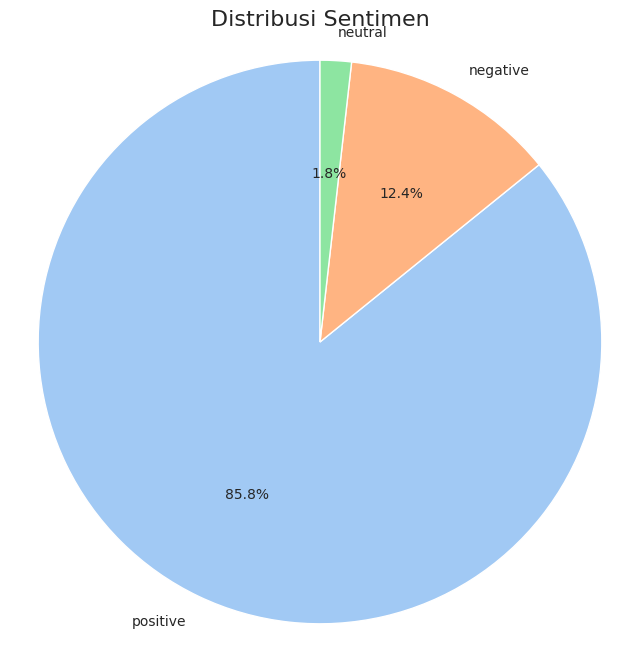

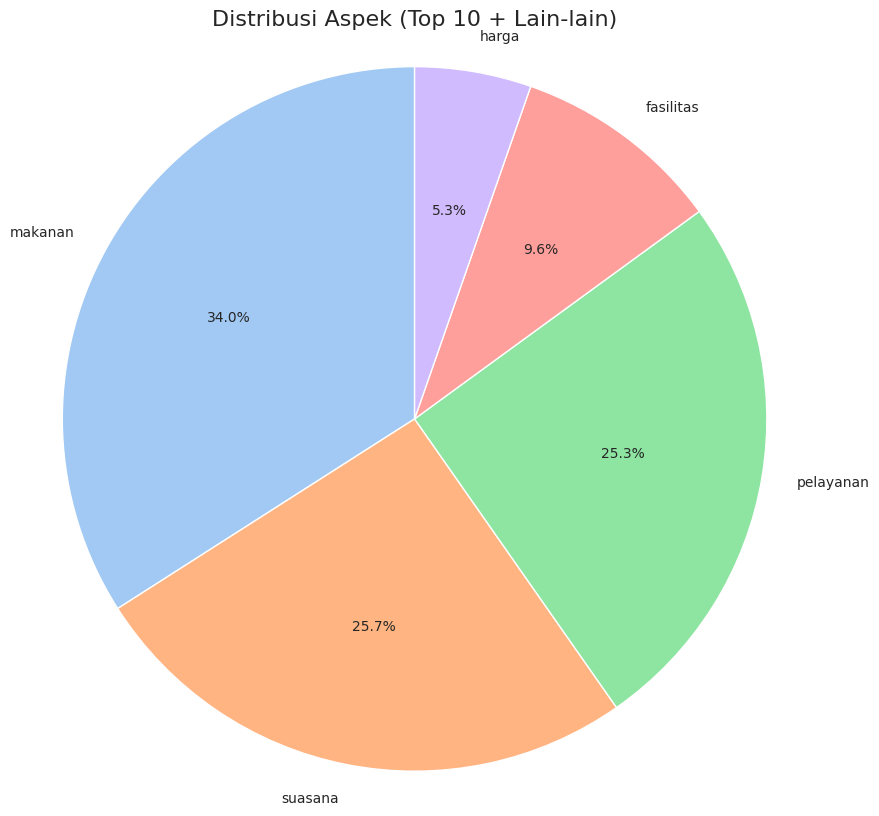

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd # Import pandas, as it's used for Series operations

# Set Seaborn style for better aesthetics
sns.set_style("whitegrid")

# --- 1. Pie Chart for Sentiment Distribution ---

sentiment_counts = df_reviews['sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribusi Sentimen', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# --- 2. Pie Chart for Aspect Distribution ---

# Flatten the list of aspects
all_aspects = [aspect for sublist in df_reviews['aspect_classification'] for aspect in sublist]

# Count the occurrences of each aspect
aspect_counts = Counter(all_aspects)

# Convert to a pandas Series for easy plotting
aspect_series = pd.Series(aspect_counts).sort_values(ascending=False)

# Filter out 'None' if it exists and is not desired in the plot
if 'None' in aspect_series.index:
    aspect_series = aspect_series.drop('None')

# You might want to limit the number of aspects if there are too many
# For example, show top 10 aspects and group the rest as 'Other'
if len(aspect_series) > 10:
    top_aspects = aspect_series.head(10)
    other_count = aspect_series.iloc[10:].sum()
    # Use pd.concat() instead of .append()
    aspect_for_plot = pd.concat([top_aspects, pd.Series({'Lain-lain': other_count})])
else:
    aspect_for_plot = aspect_series

plt.figure(figsize=(10, 10))
plt.pie(aspect_for_plot, labels=aspect_for_plot.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribusi Aspek (Top 10 + Lain-lain)', fontsize=16)
plt.axis('equal')
plt.show()

/tmp/ipykernel_1577/2134237101.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspect_for_plot.index, y=aspect_for_plot.values, palette='viridis')


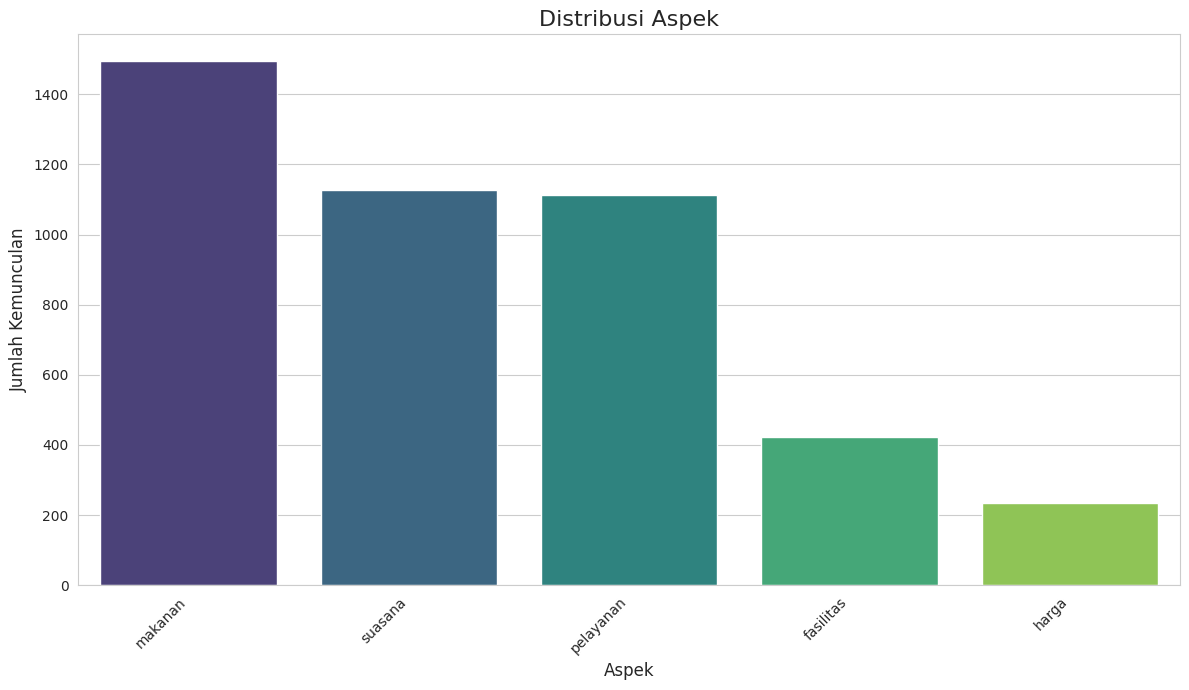

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure aspect_for_plot is defined, which it should be from previous cells
# if 'aspect_for_plot' is not available, you might need to re-run previous cells
# For robustness, we can check if it exists or recreate it if needed

if 'aspect_for_plot' not in locals():
    from collections import Counter
    # Flatten the list of aspects
    all_aspects = [aspect for sublist in df_reviews['aspect_classification'] for aspect in sublist]
    # Count the occurrences of each aspect
    aspect_counts = Counter(all_aspects)
    # Convert to a pandas Series for easy plotting
    aspect_series = pd.Series(aspect_counts).sort_values(ascending=False)
    if 'None' in aspect_series.index:
        aspect_series = aspect_series.drop('None')
    if len(aspect_series) > 10:
        top_aspects = aspect_series.head(10)
        other_count = aspect_series.iloc[10:].sum()
        aspect_for_plot = pd.concat([top_aspects, pd.Series({'Lain-lain': other_count})])
    else:
        aspect_for_plot = aspect_series

plt.figure(figsize=(12, 7))
sns.barplot(x=aspect_for_plot.index, y=aspect_for_plot.values, palette='viridis')
plt.title('Distribusi Aspek', fontsize=16)
plt.xlabel('Aspek', fontsize=12)
plt.ylabel('Jumlah Kemunculan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()